In [6]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
import os

DATA_PATH = "data/Audio_Speech_Actors_01-24"

print("Dataset exists:", os.path.exists(DATA_PATH))

if os.path.exists(DATA_PATH):
    actors = os.listdir(DATA_PATH)
    print("Number of folders:", len(actors))
    print("First few folders:", actors[:5])

Dataset exists: True
Number of folders: 24
First few folders: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [8]:
# Find the first .wav file in the dataset

audio_file = None

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith(".wav"):
            audio_file = os.path.join(root, file)
            break
    if audio_file:
        break

print("Audio file:")
print(audio_file)

Audio file:
data/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav


In [9]:
# Load the audio

audio, sample_rate = librosa.load(audio_file, sr=None)

print("Sample rate:", sample_rate)
print("Audio length:", len(audio))
print("Duration:", len(audio) / sample_rate, "seconds")

Sample rate: 48000
Audio length: 158558
Duration: 3.3032916666666665 seconds


In [10]:
# Extract MFCC features from an audio file

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

print("MFCC shape:", mfcc.shape)

MFCC shape: (40, 310)


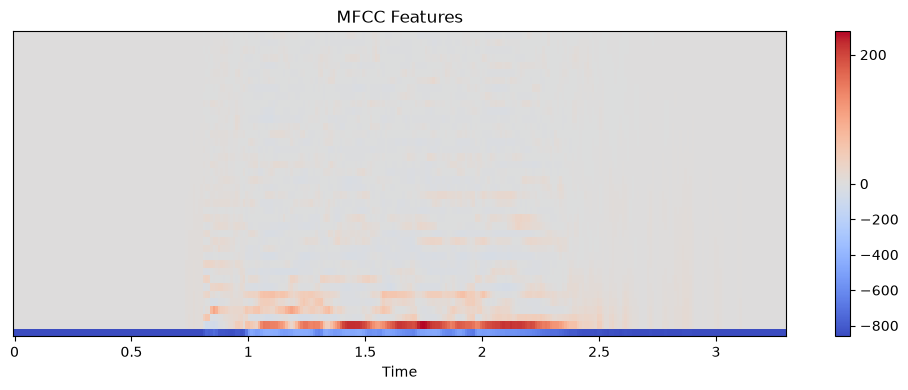

In [11]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sample_rate
)

plt.colorbar()
plt.title("MFCC Features")
plt.tight_layout()
plt.show()

In [12]:
# RAVDESS emotion codes

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

print(emotion_map)

{'01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad', '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'}


In [13]:
# Extract MFCC features from the entire RAVDESS dataset

features = []
labels = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:

        if not file.endswith(".wav"):
            continue

        # Get emotion code from filename
        emotion_code = file.split("-")[2]

        # Convert code to emotion name
        emotion = emotion_map.get(emotion_code)

        if emotion is None:
            continue

        file_path = os.path.join(root, file)

        try:
            # Load audio
            audio, sample_rate = librosa.load(file_path, sr=None)

            # Extract 40 MFCCs
            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=sample_rate,
                n_mfcc=40
            )

            # Average across time
            mfcc_features = np.mean(mfcc.T, axis=0)

            features.append(mfcc_features)
            labels.append(emotion)

        except Exception as e:
            print("Error processing:", file_path)
            print(e)

print("Feature extraction complete!")
print("Number of audio files processed:", len(features))
print("Number of labels:", len(labels))

Feature extraction complete!
Number of audio files processed: 1440
Number of labels: 1440


In [14]:
# Create a DataFrame

features_df = pd.DataFrame(features)
features_df["emotion"] = labels

print("Dataset shape:", features_df.shape)

display(features_df.head())

Dataset shape: (1440, 41)


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,emotion
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667408,-2.983828,3.098029,-3.310813,-1.564384,...,-1.399110,-2.926856,0.013957,-0.490734,-0.570905,0.040399,-1.207217,-1.594982,-1.436487,neutral
1,-719.128296,70.201569,1.168397,13.122543,7.836950,14.411290,-4.111360,4.468973,-3.539367,-3.658607,...,-2.521470,-2.987673,0.409735,-0.484184,-1.398391,0.255203,-0.984978,-2.093061,-1.040791,neutral
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,...,-0.909152,-3.045955,-0.373294,-0.849145,-0.922105,-0.170320,-1.144423,-1.725612,-1.450560,neutral
3,-710.975281,67.564880,5.782240,13.230727,6.190845,12.628252,-1.675169,5.657494,-4.950634,-3.477545,...,-1.329651,-2.513405,-0.190276,-0.645949,-0.553919,0.459299,-1.580085,-1.647682,-1.509511,neutral
4,-759.921753,75.783524,6.023605,14.557394,6.454188,14.631508,-3.004551,4.620970,-5.200016,-0.707430,...,-2.188582,-2.835501,0.463746,-1.019167,-1.411440,0.350433,-1.519892,-1.250112,-0.613852,calm


In [15]:
# Separate input features and emotion labels

X = features_df.drop("emotion", axis=1).values
y = features_df["emotion"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1440, 40)
y shape: (1440,)


In [16]:
# Encode emotion labels

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Emotion classes:")
print(label_encoder.classes_)

Emotion classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [17]:
# Split into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1152
Testing samples: 288


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling complete!")

Feature scaling complete!


In [19]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Tensor shapes:")
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

Tensor shapes:
X_train: torch.Size([1152, 40])
y_train: torch.Size([1152])


In [20]:
# Create PyTorch DataLoaders

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [21]:
# 1D Convolutional Neural Network

import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class EmotionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 10, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 8)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = EmotionCNN().to(device)

print("Using device:", device)
print(model)

Using device: cpu
EmotionCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=640, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
)


In [22]:
# Loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Training setup complete!")

Training setup complete!


In [23]:
# Train the CNN

num_epochs = 20

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        # CNN expects: batch, channels, features
        inputs = inputs.unsqueeze(1).to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/20] Loss: 1.9878 Accuracy: 21.35%
Epoch [2/20] Loss: 1.8150 Accuracy: 30.38%
Epoch [3/20] Loss: 1.6531 Accuracy: 40.10%
Epoch [4/20] Loss: 1.5642 Accuracy: 41.58%
Epoch [5/20] Loss: 1.4637 Accuracy: 45.14%
Epoch [6/20] Loss: 1.3512 Accuracy: 48.44%
Epoch [7/20] Loss: 1.2689 Accuracy: 53.47%
Epoch [8/20] Loss: 1.1903 Accuracy: 56.86%
Epoch [9/20] Loss: 1.1390 Accuracy: 59.11%
Epoch [10/20] Loss: 1.0506 Accuracy: 60.94%
Epoch [11/20] Loss: 0.9803 Accuracy: 65.97%
Epoch [12/20] Loss: 0.9264 Accuracy: 66.23%
Epoch [13/20] Loss: 0.8501 Accuracy: 71.09%
Epoch [14/20] Loss: 0.7782 Accuracy: 73.35%
Epoch [15/20] Loss: 0.7427 Accuracy: 74.48%
Epoch [16/20] Loss: 0.6772 Accuracy: 77.08%
Epoch [17/20] Loss: 0.6276 Accuracy: 77.78%
Epoch [18/20] Loss: 0.5948 Accuracy: 80.56%
Epoch [19/20] Loss: 0.5518 Accuracy: 81.77%
Epoch [20/20] Loss: 0.5115 Accuracy: 82.38%


In [24]:
# Evaluate the model on the test dataset

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:

        inputs = inputs.unsqueeze(1).to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 60.42%


In [25]:
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_
    )
)


Classification Report:

              precision    recall  f1-score   support

       angry       0.73      0.79      0.76        38
        calm       0.63      0.87      0.73        38
     disgust       0.59      0.58      0.59        38
     fearful       0.60      0.72      0.65        39
       happy       0.55      0.28      0.37        39
     neutral       0.40      0.32      0.35        19
         sad       0.63      0.50      0.56        38
   surprised       0.54      0.64      0.59        39

    accuracy                           0.60       288
   macro avg       0.59      0.59      0.58       288
weighted avg       0.60      0.60      0.59       288



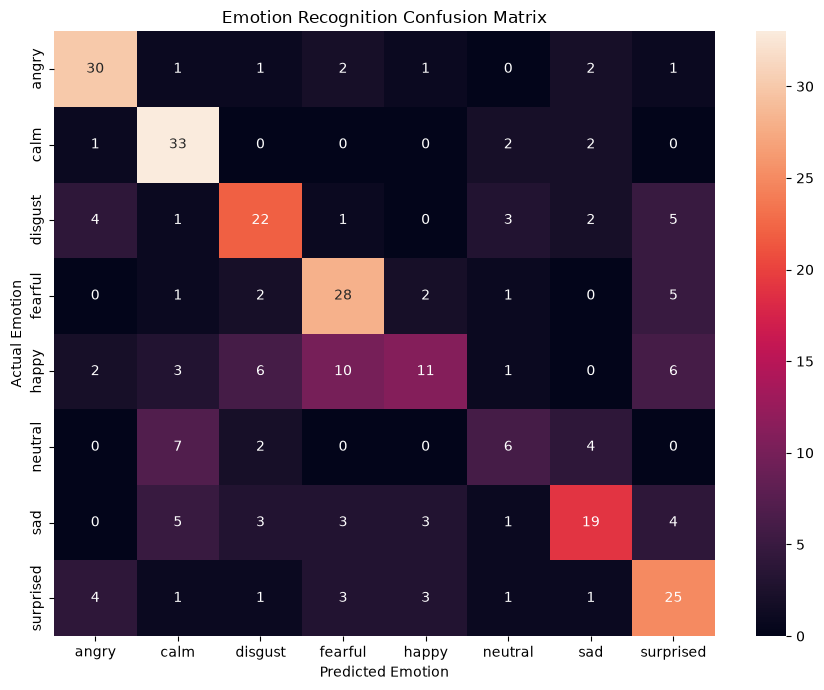

In [26]:
# Confusion Matrix

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Emotion Recognition Confusion Matrix")
plt.tight_layout()
plt.show()

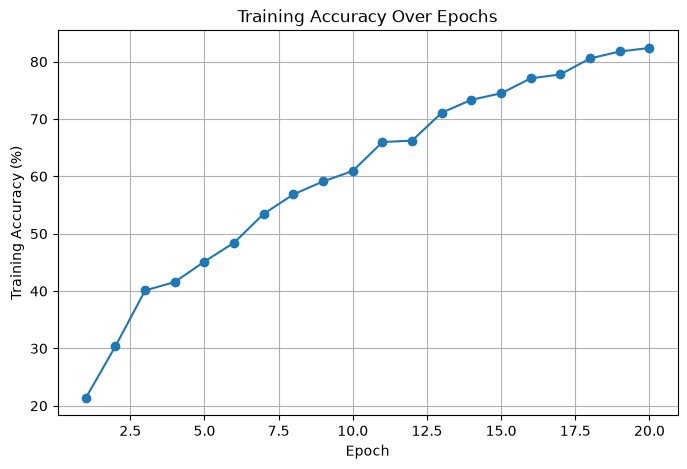

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Over Epochs")
plt.grid(True)
plt.show()

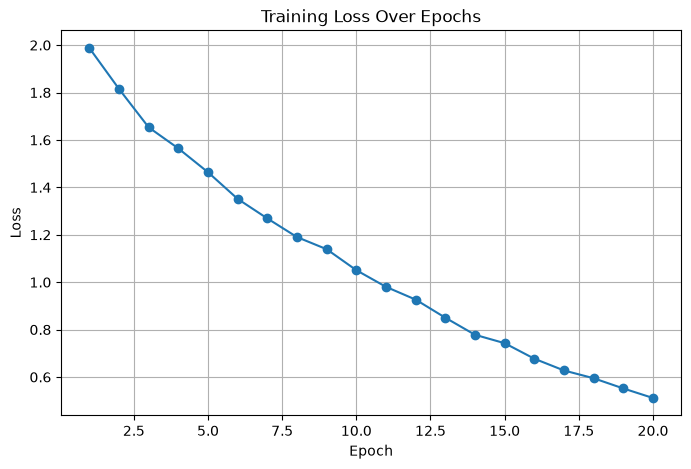

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

In [29]:
# Save the trained model

torch.save(model.state_dict(), "emotion_cnn.pth")

print("Model saved successfully!")

Model saved successfully!


In [30]:
# Save preprocessing objects

import joblib

joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Label encoder and scaler saved successfully!")

Label encoder and scaler saved successfully!


In [31]:
# Test the model on one audio file

test_audio_path = audio_file

audio, sample_rate = librosa.load(
    test_audio_path,
    sr=None
)

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

mfcc_features = np.mean(mfcc.T, axis=0)

# Apply the same scaling used during training
mfcc_scaled = scaler.transform([mfcc_features])

# Convert to PyTorch tensor
input_tensor = torch.tensor(
    mfcc_scaled,
    dtype=torch.float32
).unsqueeze(1).to(device)

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    prediction = torch.argmax(output, dim=1).item()

predicted_emotion = label_encoder.inverse_transform(
    [prediction]
)[0]

print("Audio file:", os.path.basename(test_audio_path))
print("Predicted emotion:", predicted_emotion)

Audio file: 03-01-01-01-01-01-01.wav
Predicted emotion: happy


In [32]:
# Compare actual and predicted emotion

filename = os.path.basename(test_audio_path)

emotion_code = filename.split("-")[2]

actual_emotion = emotion_map[emotion_code]

print("Actual emotion:", actual_emotion)
print("Predicted emotion:", predicted_emotion)

if actual_emotion == predicted_emotion:
    print("Result: Correct prediction ✅")
else:
    print("Result: Incorrect prediction ❌")

Actual emotion: neutral
Predicted emotion: happy
Result: Incorrect prediction ❌


In [33]:
# Improved MFCC extraction
# Keep the full time dimension instead of averaging it

mfcc_features_full = []
labels_full = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if not file.endswith(".wav"):
            continue

        emotion_code = file.split("-")[2]
        emotion = emotion_map.get(emotion_code)

        if emotion is None:
            continue

        file_path = os.path.join(root, file)

        try:
            audio, sample_rate = librosa.load(file_path, sr=16000)

            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=sample_rate,
                n_mfcc=40
            )

            mfcc_features_full.append(mfcc)
            labels_full.append(emotion)

        except Exception as e:
            print("Error:", file_path)
            print(e)

print("Improved feature extraction complete!")
print("Number of audio files:", len(mfcc_features_full))
print("Example MFCC shape:", mfcc_features_full[0].shape)

Improved feature extraction complete!
Number of audio files: 1440
Example MFCC shape: (40, 104)


In [34]:
# Make all MFCCs the same size

max_length = max(mfcc.shape[1] for mfcc in mfcc_features_full)

print("Maximum MFCC time length:", max_length)

X_full = []

for mfcc in mfcc_features_full:
    if mfcc.shape[1] < max_length:
        pad_width = max_length - mfcc.shape[1]

        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, pad_width)),
            mode="constant"
        )

    else:
        mfcc = mfcc[:, :max_length]

    X_full.append(mfcc)

X_full = np.array(X_full)

print("Final feature shape:", X_full.shape)

Maximum MFCC time length: 165
Final feature shape: (1440, 40, 165)


In [35]:
# Encode emotion labels

label_encoder_full = LabelEncoder()
y_full = label_encoder_full.fit_transform(labels_full)

print("Emotion classes:")
print(label_encoder_full.classes_)

Emotion classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [36]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print("Training shape:", X_train_full.shape)
print("Testing shape:", X_test_full.shape)

Training shape: (1152, 40, 165)
Testing shape: (288, 40, 165)


In [37]:
# Normalize MFCC features

mean = X_train_full.mean()
std = X_train_full.std()

X_train_full = (X_train_full - mean) / (std + 1e-8)
X_test_full = (X_test_full - mean) / (std + 1e-8)

print("MFCC normalization complete!")

MFCC normalization complete!


In [38]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor_full = torch.tensor(
    X_train_full, dtype=torch.float32
).unsqueeze(1)

X_test_tensor_full = torch.tensor(
    X_test_full, dtype=torch.float32
).unsqueeze(1)

y_train_tensor_full = torch.tensor(
    y_train_full, dtype=torch.long
)

y_test_tensor_full = torch.tensor(
    y_test_full, dtype=torch.long
)

print("Training tensor shape:", X_train_tensor_full.shape)
print("Testing tensor shape:", X_test_tensor_full.shape)

Training tensor shape: torch.Size([1152, 1, 40, 165])
Testing tensor shape: torch.Size([288, 1, 40, 165])


In [39]:
train_dataset_full = TensorDataset(
    X_train_tensor_full,
    y_train_tensor_full
)

test_dataset_full = TensorDataset(
    X_test_tensor_full,
    y_test_tensor_full
)

train_loader_full = DataLoader(
    train_dataset_full,
    batch_size=32,
    shuffle=True
)

test_loader_full = DataLoader(
    test_dataset_full,
    batch_size=32,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [40]:
import torch.nn as nn
import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class EmotionCNN2D(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 8))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 8)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_2d = EmotionCNN2D().to(device)

print(model_2d)

EmotionCNN2D(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(4, 8))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout

In [41]:
criterion_2d = nn.CrossEntropyLoss()

optimizer_2d = optim.Adam(
    model_2d.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [42]:
num_epochs_2d = 25

train_losses_2d = []
train_accuracies_2d = []

for epoch in range(num_epochs_2d):

    model_2d.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_full:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer_2d.zero_grad()

        outputs = model_2d(inputs)

        loss = criterion_2d(outputs, labels)

        loss.backward()
        optimizer_2d.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader_full)
    epoch_accuracy = 100 * correct / total

    train_losses_2d.append(epoch_loss)
    train_accuracies_2d.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs_2d}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

KeyboardInterrupt: 

In [ ]:
# Evaluate the improved 2D CNN

model_2d.eval()

all_predictions_2d = []
all_labels_2d = []

with torch.no_grad():
    for inputs, labels in test_loader_full:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_2d(inputs)

        _, predictions = torch.max(outputs, 1)

        all_predictions_2d.extend(
            predictions.cpu().numpy()
        )

        all_labels_2d.extend(
            labels.cpu().numpy()
        )

test_accuracy_2d = accuracy_score(
    all_labels_2d,
    all_predictions_2d
)

print(
    f"Improved 2D CNN Test Accuracy: "
    f"{test_accuracy_2d * 100:.2f}%"
)

Improved 2D CNN Test Accuracy: 53.82%


In [ ]:
print(classification_report(
    all_labels_2d,
    all_predictions_2d,
    target_names=label_encoder_full.classes_
))

              precision    recall  f1-score   support

       angry       0.67      0.76      0.72        38
        calm       0.71      0.26      0.38        38
     disgust       0.41      0.92      0.56        38
     fearful       0.65      0.38      0.48        39
       happy       0.62      0.41      0.49        39
     neutral       0.38      0.32      0.34        19
         sad       0.32      0.26      0.29        38
   surprised       0.69      0.87      0.77        39

    accuracy                           0.54       288
   macro avg       0.56      0.52      0.51       288
weighted avg       0.57      0.54      0.52       288



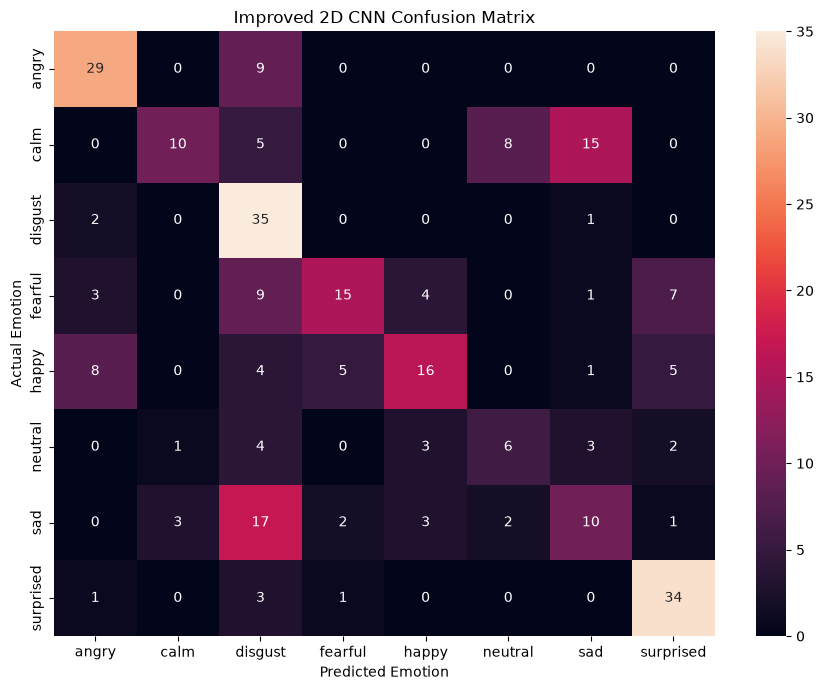

In [ ]:
cm_2d = confusion_matrix(
    all_labels_2d,
    all_predictions_2d
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_2d,
    annot=True,
    fmt="d",
    xticklabels=label_encoder_full.classes_,
    yticklabels=label_encoder_full.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Improved 2D CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Improved feature extraction:
# MFCC + Delta + Delta-Delta

features_advanced = []
labels_advanced = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:

        if not file.endswith(".wav"):
            continue

        emotion_code = file.split("-")[2]
        emotion = emotion_map.get(emotion_code)

        if emotion is None:
            continue

        file_path = os.path.join(root, file)

        try:
            audio, sample_rate = librosa.load(
                file_path,
                sr=16000
            )

            # 40 MFCC features
            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=sample_rate,
                n_mfcc=40
            )

            # First-order change
            delta = librosa.feature.delta(mfcc)

            # Second-order change
            delta_delta = librosa.feature.delta(
                mfcc,
                order=2
            )

            # Combine them
            combined = np.concatenate(
                [mfcc, delta, delta_delta],
                axis=0
            )

            features_advanced.append(combined)
            labels_advanced.append(emotion)

        except Exception as e:
            print("Error processing:", file_path)
            print(e)

print("Advanced feature extraction complete!")
print("Number of audio files:", len(features_advanced))
print("Example shape:", features_advanced[0].shape)

Advanced feature extraction complete!
Number of audio files: 1440
Example shape: (120, 104)


In [ ]:
max_length_advanced = max(
    mfcc.shape[1]
    for mfcc in features_advanced
)

print(
    "Maximum time length:",
    max_length_advanced
)

X_advanced = []

for mfcc in features_advanced:

    if mfcc.shape[1] < max_length_advanced:

        pad_width = (
            max_length_advanced -
            mfcc.shape[1]
        )

        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, pad_width)),
            mode="constant"
        )

    else:

        mfcc = mfcc[
            :,
            :max_length_advanced
        ]

    X_advanced.append(mfcc)

X_advanced = np.array(X_advanced)

print(
    "Final advanced feature shape:",
    X_advanced.shape
)

Maximum time length: 165
Final advanced feature shape: (1440, 120, 165)


In [ ]:
label_encoder_advanced = LabelEncoder()

y_advanced = label_encoder_advanced.fit_transform(
    labels_advanced
)

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced,
    y_advanced,
    test_size=0.2,
    random_state=42,
    stratify=y_advanced
)

print("Training:", X_train_adv.shape)
print("Testing:", X_test_adv.shape)

Training: (1152, 120, 165)
Testing: (288, 120, 165)


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_adv_tensor = torch.tensor(
    X_train_adv,
    dtype=torch.float32
)

X_test_adv_tensor = torch.tensor(
    X_test_adv,
    dtype=torch.float32
)

y_train_adv_tensor = torch.tensor(
    y_train_adv,
    dtype=torch.long
)

y_test_adv_tensor = torch.tensor(
    y_test_adv,
    dtype=torch.long
)

print("Training tensor shape:", X_train_adv_tensor.shape)
print("Testing tensor shape:", X_test_adv_tensor.shape)

Training tensor shape: torch.Size([1152, 120, 165])
Testing tensor shape: torch.Size([288, 120, 165])


In [ ]:
train_dataset_adv = TensorDataset(
    X_train_adv_tensor,
    y_train_adv_tensor
)

test_dataset_adv = TensorDataset(
    X_test_adv_tensor,
    y_test_adv_tensor
)

train_loader_adv = DataLoader(
    train_dataset_adv,
    batch_size=32,
    shuffle=True
)

test_loader_adv = DataLoader(
    test_dataset_adv,
    batch_size=32,
    shuffle=False
)

print("Advanced DataLoaders created successfully!")

Advanced DataLoaders created successfully!


In [ ]:
import torch.nn as nn
import torch.optim as optim

class AdvancedEmotionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=120,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 8)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_adv = AdvancedEmotionCNN().to(device)

print(model_adv)

AdvancedEmotionCNN(
  (features): Sequential(
    (0): Conv1d(120, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inpla

In [ ]:
criterion_adv = nn.CrossEntropyLoss()

optimizer_adv = optim.Adam(
    model_adv.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

print("Advanced model ready!")

Advanced model ready!


In [ ]:
num_epochs_adv = 25

train_losses_adv = []
train_accuracies_adv = []

for epoch in range(num_epochs_adv):

    model_adv.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_adv:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer_adv.zero_grad()

        outputs = model_adv(inputs)

        loss = criterion_adv(outputs, labels)

        loss.backward()
        optimizer_adv.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = (
        running_loss /
        len(train_loader_adv)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    train_losses_adv.append(epoch_loss)
    train_accuracies_adv.append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs_adv}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/25] Loss: 1.9284 Accuracy: 25.61%
Epoch [2/25] Loss: 1.6812 Accuracy: 38.45%
Epoch [3/25] Loss: 1.4757 Accuracy: 48.87%
Epoch [4/25] Loss: 1.2827 Accuracy: 53.47%
Epoch [5/25] Loss: 1.1230 Accuracy: 58.77%
Epoch [6/25] Loss: 0.9916 Accuracy: 65.97%
Epoch [7/25] Loss: 0.9017 Accuracy: 67.19%
Epoch [8/25] Loss: 0.8025 Accuracy: 71.01%
Epoch [9/25] Loss: 0.6777 Accuracy: 76.82%
Epoch [10/25] Loss: 0.5997 Accuracy: 79.43%
Epoch [11/25] Loss: 0.5422 Accuracy: 82.29%
Epoch [12/25] Loss: 0.4383 Accuracy: 85.76%
Epoch [13/25] Loss: 0.4094 Accuracy: 86.81%
Epoch [14/25] Loss: 0.3389 Accuracy: 90.28%
Epoch [15/25] Loss: 0.2942 Accuracy: 90.62%
Epoch [16/25] Loss: 0.2650 Accuracy: 92.36%
Epoch [17/25] Loss: 0.2114 Accuracy: 93.84%
Epoch [18/25] Loss: 0.2280 Accuracy: 92.88%
Epoch [19/25] Loss: 0.1785 Accuracy: 96.27%
Epoch [20/25] Loss: 0.1468 Accuracy: 95.92%
Epoch [21/25] Loss: 0.1226 Accuracy: 97.14%
Epoch [22/25] Loss: 0.1235 Accuracy: 97.14%
Epoch [23/25] Loss: 0.1086 Accuracy: 97.4

In [ ]:
model_adv.eval()

all_predictions_adv = []
all_labels_adv = []

with torch.no_grad():

    for inputs, labels in test_loader_adv:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_adv(inputs)

        _, predictions = torch.max(
            outputs,
            1
        )

        all_predictions_adv.extend(
            predictions.cpu().numpy()
        )

        all_labels_adv.extend(
            labels.cpu().numpy()
        )

test_accuracy_adv = accuracy_score(
    all_labels_adv,
    all_predictions_adv
)

print(
    f"Advanced CNN Test Accuracy: "
    f"{test_accuracy_adv * 100:.2f}%"
)

Advanced CNN Test Accuracy: 74.31%


In [ ]:
print(classification_report(
    all_labels_adv,
    all_predictions_adv,
    target_names=label_encoder_advanced.classes_
))

              precision    recall  f1-score   support

       angry       0.82      0.84      0.83        38
        calm       0.85      0.87      0.86        38
     disgust       0.91      0.82      0.86        38
     fearful       0.62      0.87      0.72        39
       happy       0.56      0.49      0.52        39
     neutral       0.54      0.68      0.60        19
         sad       0.75      0.63      0.69        38
   surprised       0.90      0.72      0.80        39

    accuracy                           0.74       288
   macro avg       0.74      0.74      0.74       288
weighted avg       0.76      0.74      0.74       288



In [ ]:
print(classification_report(
    all_labels_adv,
    all_predictions_adv,
    target_names=label_encoder_advanced.classes_
))

              precision    recall  f1-score   support

       angry       0.82      0.84      0.83        38
        calm       0.85      0.87      0.86        38
     disgust       0.91      0.82      0.86        38
     fearful       0.62      0.87      0.72        39
       happy       0.56      0.49      0.52        39
     neutral       0.54      0.68      0.60        19
         sad       0.75      0.63      0.69        38
   surprised       0.90      0.72      0.80        39

    accuracy                           0.74       288
   macro avg       0.74      0.74      0.74       288
weighted avg       0.76      0.74      0.74       288



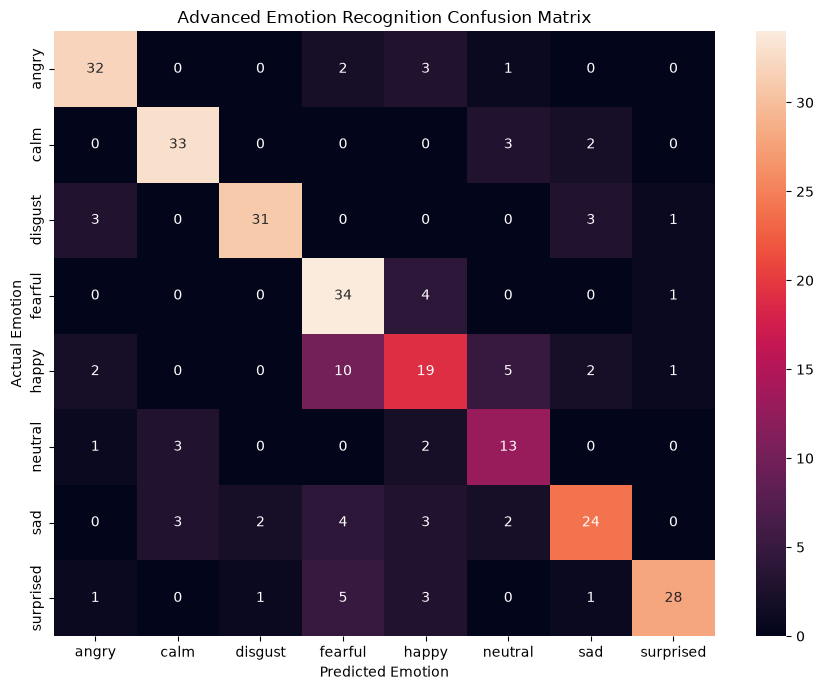

In [ ]:
cm_adv = confusion_matrix(
    all_labels_adv,
    all_predictions_adv
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_adv,
    annot=True,
    fmt="d",
    xticklabels=label_encoder_advanced.classes_,
    yticklabels=label_encoder_advanced.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Advanced Emotion Recognition Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
torch.save(
    model_adv.state_dict(),
    "emotion_cnn_advanced.pth"
)

print("Advanced model saved successfully!")

Advanced model saved successfully!


In [ ]:
import joblib

joblib.dump(
    label_encoder_advanced,
    "label_encoder_advanced.pkl"
)

print("Advanced label encoder saved!")

Advanced label encoder saved!


In [ ]:
# Recalculate and save normalization values

mean_adv = X_train_adv.mean()
std_adv = X_train_adv.std()

np.save("mfcc_mean.npy", mean_adv)
np.save("mfcc_std.npy", std_adv)

print("Normalization values saved successfully!")

Normalization values saved successfully!


In [ ]:
import sounddevice as sd

print("Available audio devices:")
print(sd.query_devices())

Available audio devices:
   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Internal Microphone (Conexant I, MME (2 in, 0 out)
   2 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  3 Speakers (Conexant ISST Audio), MME (0 in, 6 out)
   4 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   5 Internal Microphone (Conexant ISST Audio), Windows DirectSound (2 in, 0 out)
   6 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
   7 Speakers (Conexant ISST Audio), Windows DirectSound (0 in, 6 out)
   8 Speakers (Conexant ISST Audio), Windows WASAPI (0 in, 2 out)
   9 Internal Microphone (Conexant ISST Audio), Windows WASAPI (2 in, 0 out)
  10 Output 1 (Conexant ISST Audio output), Windows WDM-KS (0 in, 2 out)
  11 Output 2 (Conexant ISST Audio output), Windows WDM-KS (0 in, 6 out)
  12 Input (Conexant ISST Audio output), Windows WDM-KS (2 in, 0 out)
  13 Stereo Mix (Conexant ISST Stereo Mix), Windows WDM-KS (2 in, 0 out)
  14 Microphone Array (Conexant ISST A

In [ ]:
import sounddevice as sd
from scipy.io.wavfile import write

SAMPLE_RATE = 16000
DURATION = 5

print("🎙️ Get ready...")
input("Press ENTER to start recording...")

print("🔴 Recording... SPEAK NOW!")

recording = sd.rec(
    int(DURATION * SAMPLE_RATE),
    samplerate=SAMPLE_RATE,
    channels=1,
    dtype="float32"
)

sd.wait()

print("🟢 Recording finished!")

write(
    "my_voice.wav",
    SAMPLE_RATE,
    recording
)

print("Saved as: my_voice.wav")

🎙️ Get ready...
🔴 Recording... SPEAK NOW!
🟢 Recording finished!
Saved as: my_voice.wav


In [ ]:
# Extract MFCC + Delta + Delta-Delta from our recording

audio, sample_rate = librosa.load(
    "my_voice.wav",
    sr=16000
)

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

delta = librosa.feature.delta(mfcc)

delta_delta = librosa.feature.delta(
    mfcc,
    order=2
)

combined = np.concatenate(
    [mfcc, delta, delta_delta],
    axis=0
)

print("Recording feature shape:", combined.shape)

Recording feature shape: (120, 157)


In [ ]:
# Make recording the same size as the training data

target_length = X_train_adv.shape[2]

if combined.shape[1] < target_length:

    pad_width = target_length - combined.shape[1]

    combined = np.pad(
        combined,
        ((0, 0), (0, pad_width)),
        mode="constant"
    )

else:

    combined = combined[:, :target_length]

print("Final recording shape:", combined.shape)

Final recording shape: (120, 165)


In [ ]:
# Normalize using the training-data statistics

combined = (
    combined - mean_adv
) / (std_adv + 1e-8)

print("Recording normalized successfully!")

Recording normalized successfully!


In [ ]:
# Predict emotion from your voice

input_tensor = torch.tensor(
    combined,
    dtype=torch.float32
).unsqueeze(0).to(device)

model_adv.eval()

with torch.no_grad():

    output = model_adv(input_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    prediction = torch.argmax(
        output,
        dim=1
    ).item()

predicted_emotion = (
    label_encoder_advanced
    .inverse_transform([prediction])[0]
)

print("🎙️ Predicted emotion:", predicted_emotion)

🎙️ Predicted emotion: fearful


In [ ]:
print("\nEmotion probabilities:")

for emotion, probability in zip(
    label_encoder_advanced.classes_,
    probabilities[0].cpu().numpy()
):
    print(
        f"{emotion:10s}: "
        f"{probability * 100:.2f}%"
    )


Emotion probabilities:
angry     : 5.05%
calm      : 0.14%
disgust   : 0.26%
fearful   : 46.75%
happy     : 18.12%
neutral   : 5.58%
sad       : 1.08%
surprised : 23.02%


In [ ]:
# TEST THE TRAINED MODEL DIRECTLY

import os
import numpy as np
import librosa
import torch
import joblib

# --------------------------------------------------
# Find a few RAVDESS files
# --------------------------------------------------

audio_folder = "data/Audio_Speech_Actors_01-24"

files = []

for root, dirs, filenames in os.walk(audio_folder):
    for filename in filenames:
        if filename.lower().endswith(".wav"):
            files.append(os.path.join(root, filename))

print("Total audio files found:", len(files))


# --------------------------------------------------
# Pick different emotions
# --------------------------------------------------

test_files = []

for file in files:

    name = os.path.basename(file)

    parts = name.split("-")

    if len(parts) >= 3:

        emotion_code = parts[2]

        if emotion_code in ["01", "02", "03", "04", "05", "06", "07", "08"]:

            if not any(
                f.split("-")[2] == emotion_code
                for f in test_files
            ):
                test_files.append(name)


# --------------------------------------------------
# Expected emotion labels
# --------------------------------------------------

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


# --------------------------------------------------
# Load model
# --------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = AdvancedEmotionCNN().to(device)

model.load_state_dict(
    torch.load(
        "emotion_cnn_advanced.pth",
        map_location=device,
        weights_only=True
    )
)

model.eval()

label_encoder = joblib.load(
    "label_encoder_advanced.pkl"
)

mean_adv = np.load("mfcc_mean.npy")
std_adv = np.load("mfcc_std.npy")


# --------------------------------------------------
# Test function
# --------------------------------------------------

def test_file(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=16000,
        n_mfcc=40
    )

    # Delta
    delta = librosa.feature.delta(mfcc)

    # Delta-delta
    delta_delta = librosa.feature.delta(
        mfcc,
        order=2
    )

    # Combine
    features = np.concatenate(
        [
            mfcc,
            delta,
            delta_delta
        ],
        axis=0
    )

    # Pad / trim
    if features.shape[1] < 165:

        features = np.pad(
            features,
            (
                (0, 0),
                (0, 165 - features.shape[1])
            ),
            mode="constant"
        )

    else:

        features = features[:, :165]

    # Normalize
    features = (
        features - mean_adv
    ) / (
        std_adv + 1e-8
    )

    # Tensor
    x = torch.tensor(
        features,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():

        output = model(x)

        probabilities = torch.softmax(
            output,
            dim=1
        )[0].cpu().numpy()

    prediction_index = np.argmax(probabilities)

    prediction = label_encoder.inverse_transform(
        [prediction_index]
    )[0]

    return prediction, probabilities


# --------------------------------------------------
# TEST
# --------------------------------------------------

print("\n==============================")
print("MODEL DIRECT TEST")
print("==============================\n")

for filename in test_files:

    emotion_code = filename.split("-")[2]

    expected = emotion_map[emotion_code]

    full_path = None

    for file in files:

        if os.path.basename(file) == filename:
            full_path = file
            break

    prediction, probabilities = test_file(
        full_path
    )

    confidence = (
        np.max(probabilities) * 100
    )

    print(
        f"Expected: {expected:10s} | "
        f"Predicted: {prediction:10s} | "
        f"Confidence: {confidence:.2f}%"
    )

Total audio files found: 1440

MODEL DIRECT TEST

Expected: neutral    | Predicted: fearful    | Confidence: 43.42%
Expected: calm       | Predicted: fearful    | Confidence: 43.65%
Expected: happy      | Predicted: fearful    | Confidence: 44.86%
Expected: sad        | Predicted: fearful    | Confidence: 44.04%
Expected: angry      | Predicted: fearful    | Confidence: 43.73%
Expected: fearful    | Predicted: fearful    | Confidence: 44.19%
Expected: disgust    | Predicted: fearful    | Confidence: 43.86%
Expected: surprised  | Predicted: fearful    | Confidence: 44.16%


In [ ]:
import torch
import torch.nn as nn

class AdvancedEmotionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(120, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 8)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("AdvancedEmotionCNN is ready!")

AdvancedEmotionCNN is ready!


In [47]:
# ============================================================
# TEST THE SAVED MODEL ON THE EXISTING TEST DATA
# ============================================================

import torch
import numpy as np

print("X_test_adv shape:", X_test_adv.shape)
print("y_test_adv shape:", y_test_adv.shape)

# Convert test data to tensors
X_test_tensor = torch.tensor(
    X_test_adv,
    dtype=torch.float32
).to(device)

y_test_tensor = torch.tensor(
    y_test_adv,
    dtype=torch.long
).to(device)

# Make sure model is in evaluation mode
model.eval()

# Predict
with torch.no_grad():

    outputs = model(X_test_tensor)

    predictions = torch.argmax(
        outputs,
        dim=1
    )

# Accuracy
accuracy = (
    (predictions == y_test_tensor)
    .float()
    .mean()
    .item()
    * 100
)

print()
print("==============================")
print("SAVED MODEL TEST")
print("==============================")
print(f"Accuracy: {accuracy:.2f}%")
print("==============================")

NameError: name 'X_test_adv' is not defined

In [44]:
# Show variables currently available in the notebook

vars_to_check = [
    "X",
    "y",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "X_adv",
    "y_adv",
    "X_train_adv",
    "X_test_adv",
    "y_train_adv",
    "y_test_adv",
]

for name in vars_to_check:
    if name in globals():
        obj = globals()[name]
        print(f"{name}: EXISTS", end="")

        try:
            print(f" | shape = {obj.shape}")
        except:
            print()

    else:
        print(f"{name}: not found")

X: EXISTS | shape = (1440, 40)
y: EXISTS | shape = (1440,)
X_train: EXISTS | shape = (1152, 40)
X_test: EXISTS | shape = (288, 40)
y_train: EXISTS | shape = (1152,)
y_test: EXISTS | shape = (288,)
X_adv: not found
y_adv: not found
X_train_adv: not found
X_test_adv: not found
y_train_adv: not found
y_test_adv: not found
